## BASİT REGRESYON İLE 2.EL ARAÇ PİYASASINDA FİYAT TAHMİNİ VE DEGERLENDİRME

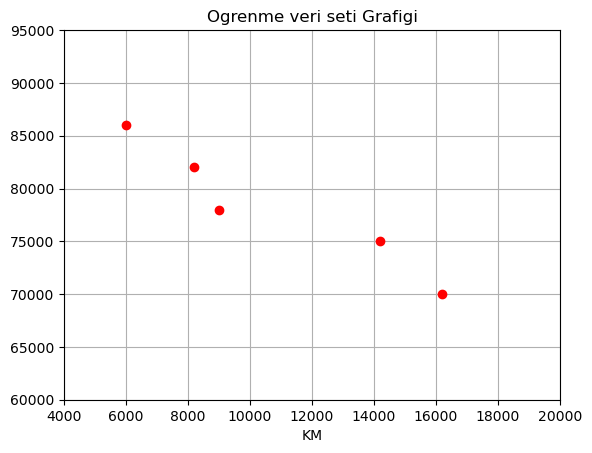

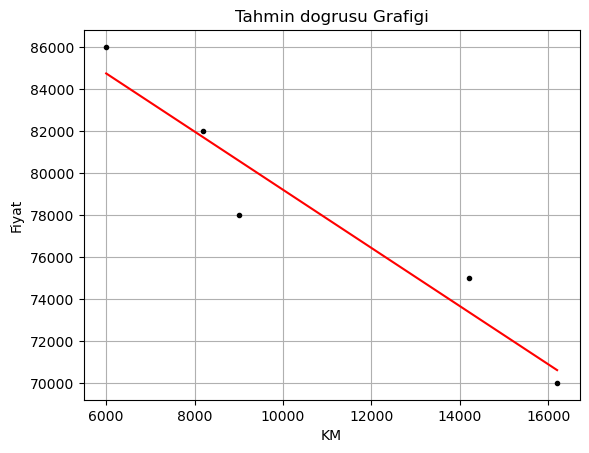

11.000 kmlik bir aracin fiyat tahmini: 77812.17
18.000 kmlik bir aracin fiyat tahmini: 68116.54


In [2]:
#Gerekli kütüpanelerin indirilmesi
import numpy as np
import matplotlib.pyplot as plt

#Öğrenme veri setini oluştuuryyoruz.x araçların kmleri,y satış fiyatını göstern birer numpy dizisi
x=np.array([[6000],[8200],[9000],[14200],[16200]]).reshape(-1,1)
y=[86000,82000,78000,75000,70000]

#Öğrenme veri setini görselleştirilmesi
plt.figure()
plt.title("Ogrenme veri seti Grafigi")
plt.xlabel("KM")
plt.plot(x,y,"ro")
plt.axis([4000,20000,60000,95000])
plt.grid(True)
plt.show()


#Basit Doğrusal regresyon modeli içi sklearn kütüphanesi
#Model oluşturma
from sklearn.linear_model import LinearRegression
model=LinearRegression( )
model.fit(x,y)

#Algoritmanın model parametrelerine bakalım:
model.intercept_
model.coef_


#Modelin tahmin doğrusunu oluşturalım:
plt.figure()
plt.title("Tahmin dogrusu Grafigi")
plt.xlabel("KM")
plt.ylabel("Fiyat")
plt.plot(x,model.predict(x),color="red")
plt.plot(x,y,"k.")
plt.grid(True)
plt.show()


#11.000 kmlik bir aracın fiyatınıa tahmin edelim:
test_araba=np.array([[11000]])
tahmin11=model.predict(test_araba)[0]
print(f"11.000 kmlik bir aracin fiyat tahmini: {tahmin11:.2f}")

#18.000 kmlik bir aracın tahmin edelim:
test_araba=np.array([[18000]])
tahmin18=model.predict(test_araba)[0]
print(f"18.000 kmlik bir aracin fiyat tahmini: {tahmin18:.2f}")




In [4]:
#modelin parametreleriyle tahmin edilen satış fiyatları karşılaştırma:
y_predictions=model.predict(x)
for i,prediction in enumerate(y_predictions):
    print(f"Tahmin edilen Fiyat: {prediction:.2f}, Gerçek Fiyat:{y[i]} ")



Tahmin edilen Fiyat: 84737.63, Gerçek Fiyat:86000 
Tahmin edilen Fiyat: 81690.43, Gerçek Fiyat:82000 
Tahmin edilen Fiyat: 80582.36, Gerçek Fiyat:78000 
Tahmin edilen Fiyat: 73379.88, Gerçek Fiyat:75000 
Tahmin edilen Fiyat: 70609.70, Gerçek Fiyat:70000 


In [6]:
#Regresyon değerlendirme ölçütlerini hesaplatıyoruz.
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score
from math import sqrt

mae = mean_absolute_error(y, y_predictions)
mse = mean_squared_error(y, y_predictions)
r2 = r2_score(y, y_predictions)
#RMSE ,MSE nin kareköküdür.
rmse=sqrt(mse)

# Sonuçları yazdır
print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"R^2 Score: {r2:.2f}")
print(f"Root Mean Squared Error:(RMSE): {rmse:.2f}")

Mean Absolute Error (MAE): 1276.82
Mean Squared Error (MSE): 2270898.44
R^2 Score: 0.93
Root Mean Squared Error:(RMSE): 1506.95


In [8]:
#Model için test veri seti oluşturalım. x_test 5 tane yeni aracın km değerleri y_test ise bu yeni aracınsatış fiyatı
x_test=np.array([[1700],[2600],[11000],[14000],[17500]]).reshape(-1,1)
y_test=[94000,94400,73000,83000,75000]



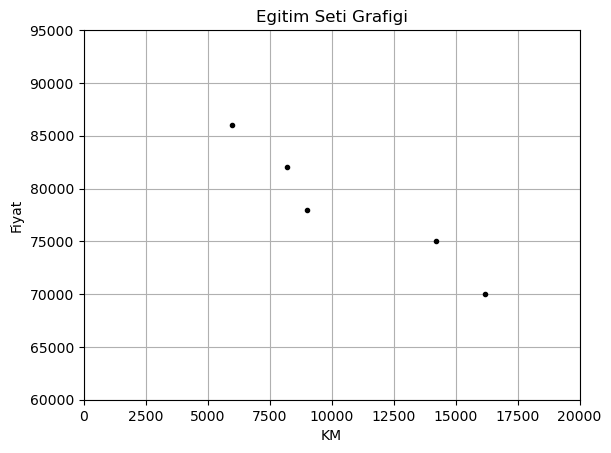

In [10]:
#Graph-1:Eğitim setinin grafiği
plt.figure()
plt.title("Egitim Seti Grafigi")
plt.xlabel("KM")
plt.ylabel("Fiyat")
plt.plot(x,y,'k.')
plt.axis([0,20000,60000,95000])
plt.grid(True)
plt.show()

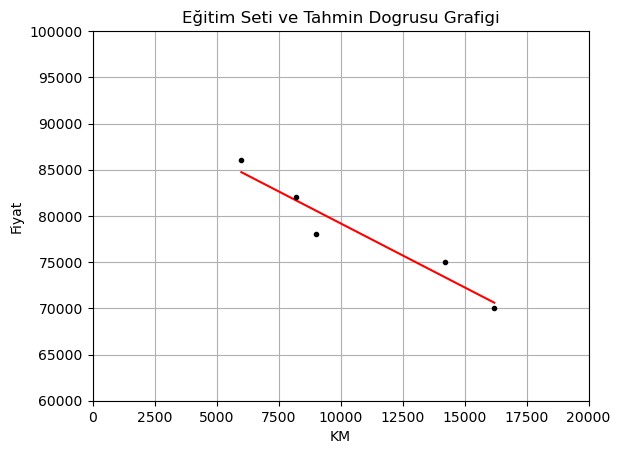

In [12]:
#Graph-2 Eğitim veri seti ve Tahmin Doğrusu
plt.figure()
plt.title("Eğitim Seti ve Tahmin Dogrusu Grafigi")
plt.xlabel("KM")
plt.ylabel("Fiyat")
plt.plot(x,model.predict(x),color="red")
plt.plot(x,y,'.',color='black')
plt.axis([0,20000,60000,100000])
plt.grid()
plt.show()


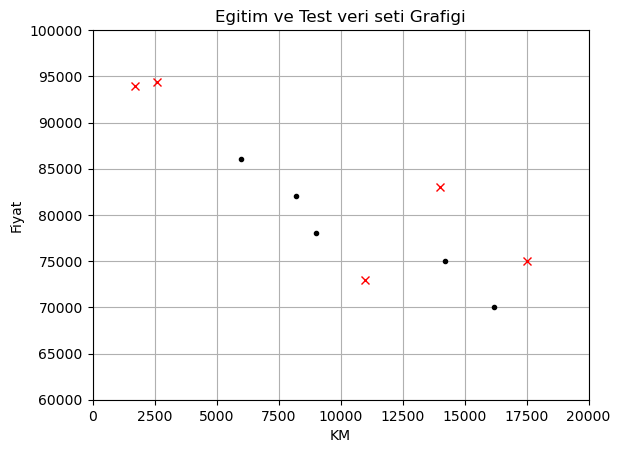

In [16]:
#Graph-3:Eğtim ve veri Test veri seti (birlikte)
plt.figure()
plt.title("Egitim ve Test veri seti Grafigi")
plt.xlabel("KM")
plt.ylabel("Fiyat")
plt.plot(x,y,'.',color="black")
plt.plot(x_test,y_test,'x',color="red")
plt.axis([0,20000,60000,100000])
plt.grid(True)
plt.show()



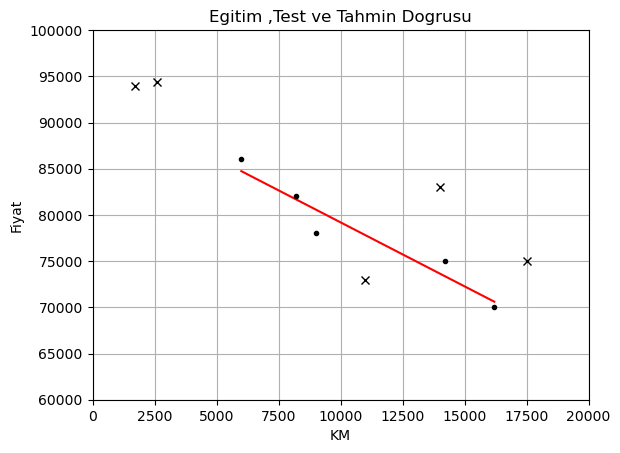

In [18]:
#Graph-4:Eğitim ve Test veri seti ile eğitim veri setinin tahmin doğrusu:
plt.figure()
plt.title("Egitim ,Test ve Tahmin Dogrusu")
plt.xlabel("KM")
plt.ylabel("Fiyat")
plt.plot(x,model.predict(x),color="red")
plt.plot(x,y,'k.')
plt.plot(x_test,y_test,'x',color="black")
plt.axis([0,20000,60000,100000])
plt.grid(True)
plt.show()


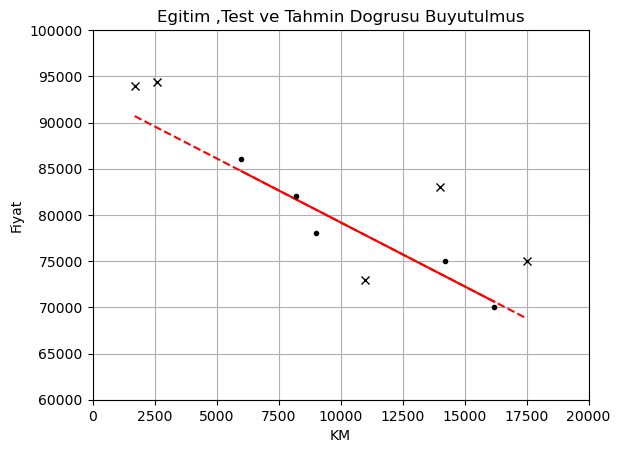

In [20]:
#Graph-5:Tahmin Doğrusu Test Veri setini başarılı öngörebiliyr mu?
plt.figure()
plt.title("Egitim ,Test ve Tahmin Dogrusu Buyutulmus")
plt.xlabel("KM")
plt.ylabel("Fiyat")
plt.plot(x,model.predict(x),color="red")
plt.plot(x_test,model.predict(x_test),"--",color='red')
plt.plot(x,y,'k.')
plt.plot(x_test,y_test,"x",color="black")
plt.axis([0,20000,60000,100000])
plt.grid(True)
plt.show()



In [24]:
#test veri seti ile tahmin seti karşılaştırma
y_test_predictions=model.predict(x_test)
for i,prediction in enumerate(y_test_predictions):
    print(f"Tahmin edilen Fiyat: {prediction:.2f}, Gerçek Fiyat {y[i]}")
    

Tahmin edilen Fiyat: 90693.52, Gerçek Fiyat 86000
Tahmin edilen Fiyat: 89446.94, Gerçek Fiyat 82000
Tahmin edilen Fiyat: 77812.17, Gerçek Fiyat 78000
Tahmin edilen Fiyat: 73656.90, Gerçek Fiyat 75000
Tahmin edilen Fiyat: 68809.08, Gerçek Fiyat 70000


In [28]:
#Regresyon skorlarını test veri seti için hesaplayalım.

mae=mean_absolute_error(y_test,y_predictions)

mse=mean_squared_error(y_test,y_predictions)

r2=r2_score(y_test,y_predictions)

rmse=sqrt(mse)

print(f"MAE: {mae:.2f}")
print(f"MSE: {mse:.2f}")
print(f"R^2: {r2:.2f}")
print(f"RMSE: {rmse:.2f}")

MAE: 8712.94
MSE: 83327638.02
R^2: -0.01
RMSE: 9128.40
